# Deep Neural Network: Application

To build your Deep Neural Network forecasting model, you'll use the functions from the previous assignment to build a deep network. Hopefully, you'll see an improvement in accuracy over your previous logistic regression implementation.  

**After this assignment you will be able to:**

- Build and train a deep L-layer neural network, and apply it to supervised learning

Let's get started!

<a name='1'></a>
## 1 - Packages

In [1]:
# Package imports
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from dnn_app_utils_v3 import *
from public_tests import *
import pandas as pd
import copy
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = pd.read_excel('Data/RawData.xlsx')
data = data.dropna()  # Remove rows with missing values

# Extract hour from the first column (date), handling invalid dates
data['datetime'] = pd.to_datetime(data.iloc[:, 0], errors='coerce')
data = data.dropna(subset=['datetime'])  # Remove rows with invalid dates
data['hour'] = data['datetime'].dt.hour
data = data.drop(columns=['datetime'])  # Remove the datetime column

# Reorder columns to make hour the second column
first_col = data.columns[0]  # First feature column
hour_col = 'hour'
remaining_cols = [col for col in data.columns if col != first_col and col != hour_col and col != data.columns[-1]]

# Reorganize: first feature, hour, remaining features, target
data = data[[first_col, hour_col] + remaining_cols]

print(data.head())

# Separate features and target variable
feature_cols = list(data.columns[1:-2])  # All columns except the last (target)
X = data[feature_cols].values.astype(float)
y = data.iloc[:, -1].values.astype(float)   # Last column is target

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = MinMaxScaler(feature_range=(0,1))
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

scaler_y = MinMaxScaler(feature_range=(0,1))
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
y_train = y_train.reshape(1, -1)
y_test = y_test.reshape(1, -1)
X_train = X_train.T
X_test = X_test.T


                  time  hour  Temperature_celcius  Rain_mm_per_h  \
0  2019-01-01 07:00:00     7                5.339          0.010   
1  2019-01-01 08:00:00     8                5.383          0.024   
2  2019-01-01 09:00:00     9                5.719          0.027   
3  2019-01-01 10:00:00    10                6.099          0.018   
4  2019-01-01 11:00:00    11                6.066          0.012   

   Snow_mm_per_h  Air density_kg_per_m3  \
0            0.0                  1.251   
1            0.0                  1.250   
2            0.0                  1.248   
3            0.0                  1.246   
4            0.0                  1.246   

   Ground_level_solar_irradiance_W_per_m2  Cloud_cover_fraction  \
0                                   1.270                 0.263   
1                                  28.815                 0.497   
2                                  55.112                 0.481   
3                                  85.135                 0.438 

<a name='2'></a>
# 2 - Load the Dataset and Normalization

In [3]:
m_train = X_train.shape[1]
m_test = X_test.shape[1]
print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("train_set_x shape: " + str(X_train.shape))
print ("train_set_y shape: " + str(y_train.shape))
print ("test_set_x shape: " + str(X_test.shape))
print ("test_set_y shape: " + str(y_test.shape))

Number of training examples: m_train = 3839
Number of testing examples: m_test = 960
train_set_x shape: (7, 3839)
train_set_y shape: (1, 3839)
test_set_x shape: (7, 960)
test_set_y shape: (1, 960)


<a name='5'></a>
## 5 - L-layer Neural Network

<a name='ex-2'></a>
### Exercise 2 - L_layer_model 

Use the helper functions you implemented previously to build an $L$-layer neural network with the following structure: *[LINEAR -> RELU]$\times$(L-1) -> LINEAR -> SIGMOID*. The functions and their inputs are:
```python
def initialize_parameters_deep(layers_dims):
    ...
    return parameters 
def L_model_forward(X, parameters):
    ...
    return AL, caches
def compute_cost(AL, Y):
    ...
    return cost
def L_model_backward(AL, Y, caches):
    ...
    return grads
def update_parameters(parameters, grads, learning_rate):
    ...
    return parameters
```

In [4]:
### CONSTANTS ###
n_x = X_train.shape[0]     # num_px * num_px * 3
print("Number of features: n_x = " + str(n_x))
n_y = y_train.shape[0]
print("Number of output units: n_y = " + str(n_y))
layers_dims = [n_x, 20, 10, 5, n_y] #  4-layer model

Number of features: n_x = 7
Number of output units: n_y = 1


In [5]:
# GRADED FUNCTION: L_layer_model

def L_layer_model(X, Y, layers_dims, learning_rate = 0.85, num_iterations = 3000, print_cost=False):
    """
    Implements a L-layer neural network: [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID.
    
    Arguments:
    X -- data, numpy array of shape (num_px * num_px * 3, number of examples)
    Y -- true "label" vector (containing 0 if cat, 1 if non-cat), of shape (1, number of examples)
    layers_dims -- list containing the input size and each layer size, of length (number of layers + 1).
    learning_rate -- learning rate of the gradient descent update rule
    num_iterations -- number of iterations of the optimization loop
    print_cost -- if True, it prints the cost every 100 steps
    
    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """

    np.random.seed(1)
    costs = []                         # keep track of cost
    
    # Parameters initialization.
    #(≈ 1 line of code)
    # parameters = ...
    # YOUR CODE STARTS HERE
    parameters = initialize_parameters_deep(layers_dims)
    # YOUR CODE ENDS HERE
    
    # Loop (gradient descent)
    for i in range(0, num_iterations):

        # Forward propagation: [LINEAR -> RELU]*(L-1) -> LINEAR -> SIGMOID.
        #(≈ 1 line of code)
        # AL, caches = ...
        # YOUR CODE STARTS HERE
        AL, caches = L_model_forward(X, parameters)
        # YOUR CODE ENDS HERE
        
        # Compute cost.
        #(≈ 1 line of code)
        # cost = ...
        # YOUR CODE STARTS HERE
        cost = compute_cost(AL, Y)
        # YOUR CODE ENDS HERE
    
        # Backward propagation.
        #(≈ 1 line of code)
        # grads = ...    
        # YOUR CODE STARTS HERE
        grads = L_model_backward(AL, Y, caches)
        # YOUR CODE ENDS HERE
 
        # Update parameters.
        #(≈ 1 line of code)
        # parameters = ...
        # YOUR CODE STARTS HERE
        parameters = update_parameters(parameters, grads, learning_rate)
        
        # YOUR CODE ENDS HERE
                
        # Print the cost every 100 iterations
        if print_cost and i % 100 == 0:
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0 or i == num_iterations:
            costs.append(cost)
    
    return parameters, costs

<a name='5-1'></a>
### 5.1 - Train the model 

If your code passed the previous cell, run the cell below to train your model as a 4-layer neural network. 

- The cost should decrease on every iteration. 

In [6]:
parameters, costs = L_layer_model(X_train, y_train, layers_dims, num_iterations = 3000, print_cost = False)
pred_train = predict(X_train, y_train, parameters)
pred_test = predict(X_test, y_test, parameters)

### Congrats! It seems that your 4-layer neural network has better performance than your 2-layer neural network on the same test set. 

This is pretty good performance for this task. Nice job! 

In [7]:
#Reverse normalization
from sklearn.preprocessing import MinMaxScaler
import numpy as np
"""
# Reverse the normalization to get the original data
Y_prediction_test_real_scale = scaler.inverse_transform(predict(test_set_x_normalized, test_set_y_normalized, parameters))"""

'\n# Reverse the normalization to get the original data\nY_prediction_test_real_scale = scaler.inverse_transform(predict(test_set_x_normalized, test_set_y_normalized, parameters))'

<a name='6'></a>
##  6 - Results Analysis

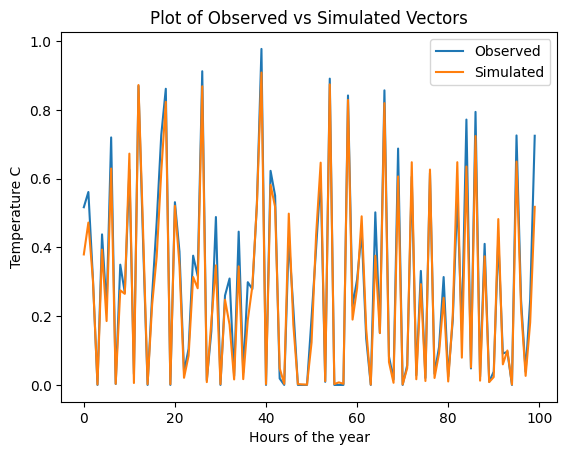

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Define the two vectors

x = np.arange(0, 100, 1)
y1 = y_test.T[:100]
y2 = pred_test.T[:100]

# Plot the vectors
plt.plot(x, y1, label='Observed')
plt.plot(x, y2, label='Simulated')

# Add a title and labels for the x and y axes
plt.title('Plot of Observed vs Simulated Vectors')
plt.xlabel('Hours of the year')
plt.ylabel('Temperature C')

# Add a legend
plt.legend()

# Display the plot
plt.show()

<a name='6'></a>
##  8 - Best hyper-parameters



In [9]:
from itertools import product
learning_rates_to_try = [0.7,0.85,0.9] 
number_of_hidden_layers_to_try = [2,3,4]
number_of_cells_per_layer_to_try = np.arange(2,6)
print_counter = 0
test_print_2 = 0
best_accuracy = 0
best_layers_dims = None
best_learning_rate = None
print(number_of_cells_per_layer_to_try)
for learning_rate_tested in learning_rates_to_try:
    for num_hidden_layers in number_of_hidden_layers_to_try:

        # Only print the first 5 combinations for readability
        print_counter = 0

        for combo in product(number_of_cells_per_layer_to_try, repeat=num_hidden_layers):

            layers_dims = (n_x,) + combo + (n_y,)

            parameters, costs = L_layer_model(X_train, y_train, layers_dims, num_iterations = 3000, print_cost = False, learning_rate=learning_rate_tested)
            
            pred_test = predict(X_test, y_test, parameters)
            accuracy=(100 - np.mean(np.abs(pred_test - y_test)) * 100) 
            if accuracy>best_accuracy : 
                best_accuracy = accuracy
                best_layers_dims = layers_dims
                best_learning_rate = learning_rate_tested
                print("new best accuracy = "+str(best_accuracy))
                print("new best layers = "+str(best_layers_dims))
                print("new best learning rate = "+str(best_learning_rate))

            




[2 3 4 5]
new best accuracy = 93.84748108986594
new best layers = (7, np.int64(2), np.int64(2), 1)
new best learning rate = 0.7
new best accuracy = 93.84977051025102
new best layers = (7, np.int64(2), np.int64(3), 1)
new best learning rate = 0.7
new best accuracy = 94.4861765002311
new best layers = (7, np.int64(2), np.int64(5), 1)
new best learning rate = 0.7
new best accuracy = 94.93660669921564
new best layers = (7, np.int64(3), np.int64(5), 1)
new best learning rate = 0.7
new best accuracy = 95.5867632540683
new best layers = (7, np.int64(4), np.int64(4), 1)
new best learning rate = 0.7
new best accuracy = 95.87197240817365
new best layers = (7, np.int64(4), np.int64(5), 1)
new best learning rate = 0.7
new best accuracy = 96.04525005306563
new best layers = (7, np.int64(3), np.int64(3), np.int64(5), 1)
new best learning rate = 0.7
new best accuracy = 96.05946310923608
new best layers = (7, np.int64(4), np.int64(5), np.int64(5), 1)
new best learning rate = 0.7
new best accuracy = 96

In [10]:
#print(best_layers_dims)
found_best_layers = [7,5,3,3,5,1]
found_best_l_r = 0.9
parameters, costs = L_layer_model(X_train, y_train, found_best_layers, num_iterations = 250000, print_cost = False, learning_rate=found_best_l_r)
pred_test = predict(X_test, y_test, parameters)
accuracy=(100 - np.mean(np.abs(pred_test - y_test)) * 100) 
print(accuracy)

97.61192713024997


MAE: 0.2018
MSE: 0.1067
RMSE: 0.3266
R²: 0.9826


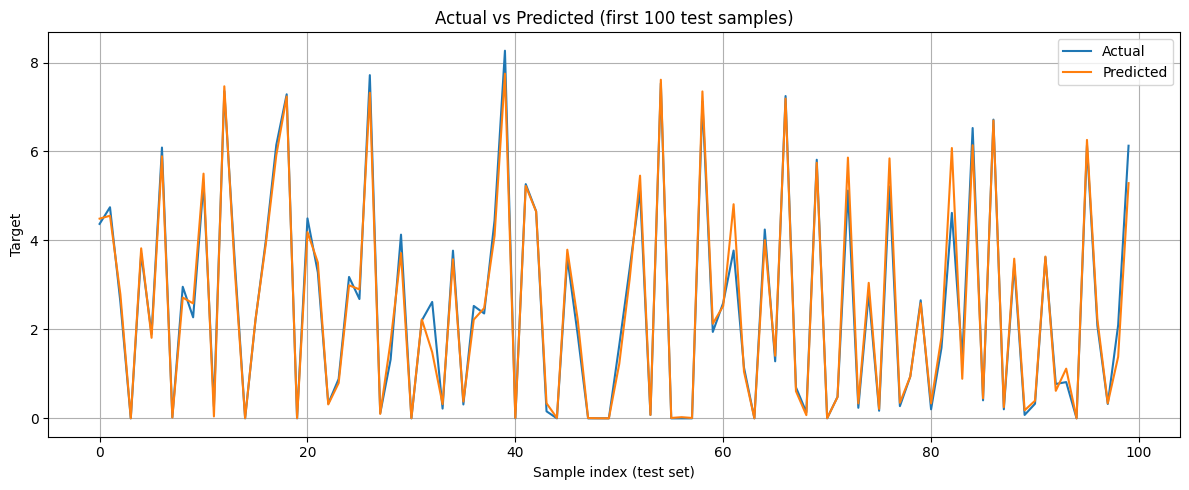

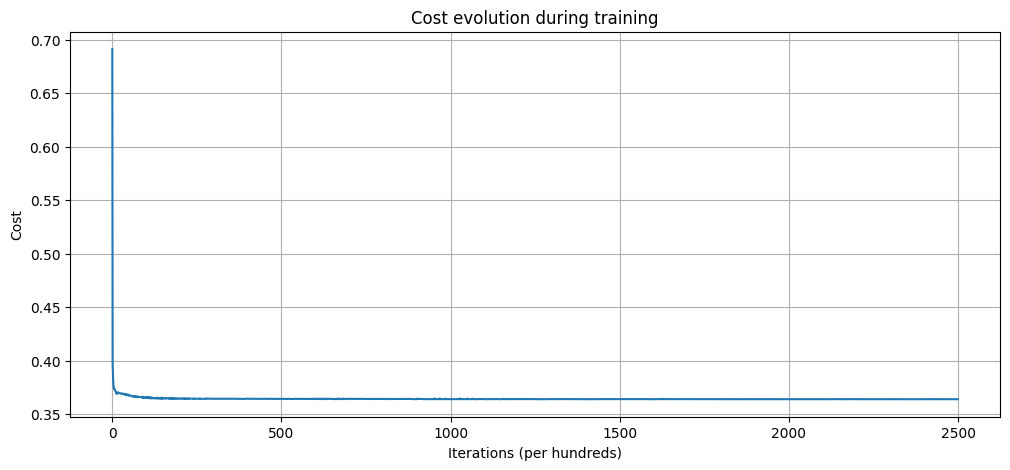

In [11]:
try:
    y_pred_inv_metrics = scaler_y.inverse_transform(pred_test.flatten().reshape(-1, 1)).flatten()
    y_actual_inv_metrics = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(y_actual_inv_metrics, y_pred_inv_metrics)
    mse = mean_squared_error(y_actual_inv_metrics, y_pred_inv_metrics)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_actual_inv_metrics, y_pred_inv_metrics)

    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
except Exception as e:
    print('Could not compute evaluation metrics:', e)

# --- Plot comparison: actual vs predicted for a few days (first ~72 points) ---
try:
    # Inverse transform predictions and ground truth back to original scale
    y_pred_test_inv = scaler_y.inverse_transform(pred_test.flatten().reshape(-1, 1)).flatten()
    y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # Number of points to show (approx. 3 days if hourly data)
    n_points = min(100, len(y_test_inv))

    plt.figure(figsize=(12, 5))
    plt.plot(range(n_points), y_test_inv[:n_points], label='Actual')
    plt.plot(range(n_points), y_pred_test_inv[:n_points], label='Predicted')
    plt.title(f'Actual vs Predicted (first {n_points} test samples)')
    plt.xlabel('Sample index (test set)')
    plt.ylabel('Target')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # costs is recorded every 100 iterations inside L_layer_model
    plt.figure(figsize=(12, 5))
    plt.plot(costs)                     # no colors specified (uses default)
    plt.ylabel("Cost")
    plt.xlabel("Iterations (per hundreds)")
    plt.title("Cost evolution during training")
    plt.grid(True)
    plt.show()
    # Show the plot. In interactive environments this will pop up; otherwise it will be saved.
    # try:
    #     plt.show()
    # except Exception:
    #     # If show() is not available (headless), save to a file instead
    #     out_path = f'Project/prediction_vs_actual_nh_{n_h}.png'
    #     plt.savefig(out_path)
    #     print(f'Plot saved to {out_path}')
except Exception as e:
    print('Could not create comparison plot:', e)